<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_SPARC_V3b_Boundary_State_Transition_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM SPARC V3b — Boundary-State Transition Notebook

This notebook continues the V3 boundary-gradient attractor test, but changes the physical implementation.

**V3 was deliberately blunt:** it treated the boundary as an additive/bounded acceleration modifier. The held-out result selected no universal correction, which means the boundary term is not yet a transferable force law.

**V3b tests the ECSM-native interpretation:** the boundary is a **response-state transition**. It should modulate activation threshold, relaxation width, and outer settling/memory, while right-censored edge boundaries should not be forced into the observed data range.

Causal chain:

\[
\rho_b(R)\rightarrow \Pi_b(R)\rightarrow \chi(R),\tau_{\rm resp}(R),\mathcal{C}_{\rm eff}(R)
\rightarrow \nabla_R\mathcal{C}_{\rm eff}(R)
\rightarrow g_{\rm eff}(R).
\]

Main additions in V3b:

1. infer a boundary-annulus radius, \(R_{\rm boundary}\);
2. classify inner, mid-disk, outer-disk, and right-censored edge boundaries;
3. test a **state-transition law** rather than an additive acceleration law;
4. perform galaxy-held-out cross-validation on shared state-transition parameters;
5. export all figures/tables/evidence files for paper/GitHub support.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELL 01 — SETUP
import os, json, zipfile, shutil, warnings, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

ROOT = Path(os.environ.get('ECSM_SPARC_V3B_ROOT', '.')).resolve()
OUTDIR = ROOT / 'ecsm_sparc_v3b_boundary_state_transition_out'
DATA_DIR = OUTDIR / 'data'
FIGDIR = OUTDIR / 'figures'
RAW_DIR = OUTDIR / 'raw'
for d in [OUTDIR, DATA_DIR, FIGDIR, RAW_DIR]:
    d.mkdir(parents=True, exist_ok=True)

KPC_TO_M = 3.0856775814913673e19
KM2_TO_M2 = 1e6
A0_DEFAULT = 1.2e-10
RNG_SEED = 11
RUN_LIMIT = None
FAST_MODE = bool(int(os.environ.get('ECSM_FAST_MODE','1')))

# Baseline finite-response grids. FAST_MODE is Colab-friendly.
if FAST_MODE:
    YD_GRID=[0.5,0.7]
    A0_GRID=[1.0e-10,1.2e-10,1.6e-10]
    R_FRAC_GRID=[0.08,0.15,0.30]
    WIDTH_FRAC_GRID=[0.05,0.12]
    S_FLOOR_GRID=[0.0,0.15,0.30]
    Q_SAT_GRID=[1.0,2.0]
    GAIN_GRID=[0.8,1.0,1.15]
    LAMBDA_RELAX_GRID=[0.0,0.4]
else:
    YD_GRID=[0.3,0.4,0.5,0.6,0.7]
    A0_GRID=[0.8e-10,1.0e-10,1.2e-10,1.4e-10,1.6e-10]
    R_FRAC_GRID=[0.05,0.08,0.12,0.18,0.25,0.35]
    WIDTH_FRAC_GRID=[0.03,0.05,0.08,0.12,0.18]
    S_FLOOR_GRID=[0.0,0.10,0.20,0.35]
    Q_SAT_GRID=[0.75,1.0,1.5,2.0,3.0]
    GAIN_GRID=[0.75,0.9,1.0,1.1,1.25]
    LAMBDA_RELAX_GRID=[0.0,0.25,0.5,0.8]

# Shared state-transition law grids.
# beta_q: earlier finite-response activation near the boundary.
# beta_tail: post-boundary settling suppression/enhancement. Positive suppresses excess response after boundary.
# beta_width: broadens the activation transition; avoids sharp overcorrection.
# beta_smooth: smooths the state field; again avoids the raw-gradient disaster.
BETA_Q_GRID=[0.0,0.10,0.20,0.35,0.50]
BETA_TAIL_GRID=[-0.20,0.0,0.15,0.30,0.50]
BETA_WIDTH_GRID=[0.0,0.30,0.60,1.00]
BETA_SMOOTH_GRID=[0.0,0.35,0.70]
CHI_P_GRID=[1.0,2.0]

EDGE_CENSOR_FRAC = 0.90   # boundaries beyond this fraction are treated as right-censored
print('OUTDIR:', OUTDIR)
print('FAST_MODE:', FAST_MODE)

OUTDIR: /content/ecsm_sparc_v3b_boundary_state_transition_out
FAST_MODE: True


## CELL 02 — Locate and load SPARC input

Preferred input is raw `Rotmod_LTG.zip`. Fallback is a point-level CSV with `galaxy, Rad, Vobs, errV, Vgas, Vdisk, Vbul`.

In [ ]:
# CELL 02 — LOCATE/PARSE INPUT

def find_files(patterns, roots):
    out=[]
    for root in roots:
        root=Path(root)
        if root.exists():
            for pat in patterns:
                out += list(root.glob(pat)) + list(root.glob('**/'+pat))
    seen=set(); clean=[]
    for p in out:
        s=str(p.resolve())
        if s not in seen:
            seen.add(s); clean.append(p)
    return clean

roots=[ROOT, Path('/content'), Path('/content/drive/MyDrive'), Path('/mnt/data')]
zips=find_files(['Rotmod_LTG.zip','*Rotmod*LTG*.zip','*rotmod*.zip'], roots)
csvs=find_files(['simplified_ecsm_curves_full.csv','*sparc*curves*.csv','v3*_curves*.csv','*.csv'], roots)
ROTMOD_ZIP=zips[0] if zips else None
POINT_CSV=csvs[0] if csvs else None
print('Rotmod zip:', ROTMOD_ZIP)
print('CSV fallback:', POINT_CSV)

if ROTMOD_ZIP is None and POINT_CSV is None:
    try:
        from google.colab import files
        uploaded=files.upload()
        for name in uploaded:
            if name.lower().endswith('.zip'):
                ROTMOD_ZIP=Path(name)
            if name.lower().endswith('.csv'):
                POINT_CSV=Path(name)
    except Exception:
        pass
if ROTMOD_ZIP is None and POINT_CSV is None:
    raise FileNotFoundError('Upload Rotmod_LTG.zip or a SPARC point-level CSV.')

ROTMOD_COLS=['Rad','Vobs','errV','Vgas','Vdisk','Vbul','SBdisk','SBbul']

def parse_rotmod_file(path):
    df=pd.read_csv(path, delim_whitespace=True, comment='#', header=None)
    if df.shape[1] < 6:
        raise ValueError(f'Too few columns in {path}')
    df.columns=ROTMOD_COLS[:df.shape[1]]
    for c in ROTMOD_COLS:
        if c not in df.columns:
            df[c]=0.0 if c in ['Vbul','SBbul'] else np.nan
    df['galaxy']=Path(path).name.replace('_rotmod.dat','').replace('.dat','')
    return df[['galaxy']+ROTMOD_COLS]

if ROTMOD_ZIP is not None:
    ex=RAW_DIR/'rotmod_extract'
    if ex.exists(): shutil.rmtree(ex)
    ex.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ROTMOD_ZIP) as z:
        z.extractall(ex)
    files=sorted(ex.glob('**/*_rotmod.dat')) or sorted(ex.glob('**/*.dat'))
    frames=[]; fails=[]
    for p in files:
        try:
            frames.append(parse_rotmod_file(p))
        except Exception as e:
            fails.append({'path':str(p),'error':repr(e)})
    all_rot=pd.concat(frames, ignore_index=True)
    pd.DataFrame(fails).to_csv(DATA_DIR/'v3b_parse_failures.csv', index=False)
else:
    all_rot=pd.read_csv(POINT_CSV)
    lower={c.lower():c for c in all_rot.columns}; ren={}
    alias={
        'galaxy':['galaxy','name','galaxy_clean'],
        'Rad':['rad','r','r_kpc','radius'],
        'Vobs':['vobs','v_obs','vrot','v_obs_kms'],
        'errV':['errv','verr','v_err','evobs'],
        'Vgas':['vgas','v_gas'],
        'Vdisk':['vdisk','v_disk'],
        'Vbul':['vbul','v_bul','vbulge']
    }
    for can,opts in alias.items():
        for opt in opts:
            if opt in lower:
                ren[lower[opt]]=can; break
    all_rot=all_rot.rename(columns=ren)
    for c in ['Vgas','Vdisk','Vbul']:
        if c not in all_rot.columns:
            all_rot[c]=0.0
    if 'errV' not in all_rot.columns:
        all_rot['errV']=np.maximum(3.0,0.05*pd.to_numeric(all_rot['Vobs'],errors='coerce'))

for c in ['Rad','Vobs','errV','Vgas','Vdisk','Vbul']:
    all_rot[c]=pd.to_numeric(all_rot[c], errors='coerce')
all_rot=all_rot.replace([np.inf,-np.inf],np.nan).dropna(subset=['galaxy','Rad','Vobs'])
all_rot=all_rot[(all_rot.Rad>0)&(all_rot.Vobs>0)].sort_values(['galaxy','Rad']).reset_index(drop=True)
all_rot.to_csv(DATA_DIR/'v3b_raw_point_table.csv', index=False)
print('Galaxies:', all_rot.galaxy.nunique(), 'Rows:', len(all_rot))
display(all_rot.head())

Rotmod zip: /content/drive/MyDrive/Rotmod_LTG.zip
CSV fallback: /content/sample_data/california_housing_train.csv
Galaxies: 175 Rows: 3391


,galaxy,Rad,Vobs,errV,Vgas,Vdisk,Vbul,SBdisk,SBbul
0,CamB,0.16,1.99,1.5,1.86,3.75,0.0,30.32,0.0
1,CamB,0.41,4.84,1.5,4.24,9.47,0.0,23.77,0.0
2,CamB,0.57,6.79,1.5,5.61,11.76,0.0,15.87,0.0
3,CamB,0.73,8.87,1.5,6.77,13.72,0.0,12.40,0.0
4,CamB,0.90,10.90,1.5,7.77,14.80,0.0,9.63,0.0


In [ ]:
# CELL 03 — BASELINE AND BOUNDARY FUNCTIONS

def signed_square(v):
    v=np.asarray(v,dtype=float)
    return np.sign(v)*v**2

def baryonic_v2(df, yd=0.5, yb=None):
    if yb is None: yb=yd
    return np.clip(signed_square(df.Vgas.values)+yd*df.Vdisk.values**2+yb*df.Vbul.values**2, 1e-12, None)

def acc_from_v2_r(v2, r):
    return np.asarray(v2)*KM2_TO_M2/(np.asarray(r)*KPC_TO_M)

def vel_from_acc(g,r):
    return np.sqrt(np.clip(np.asarray(g)*np.asarray(r)*KPC_TO_M/KM2_TO_M2,0,None))

def simple_mond(gbar,a0=A0_DEFAULT):
    gbar=np.clip(np.asarray(gbar,dtype=float),1e-30,None)
    return 0.5*(gbar+np.sqrt(gbar**2+4*a0*gbar))

def red_chi2(vobs,vmod,err,n_params=1):
    vobs=np.asarray(vobs,float); vmod=np.asarray(vmod,float); err=np.asarray(err,float)
    ok=np.isfinite(vobs)&np.isfinite(vmod)&np.isfinite(err)&(err>0)
    if ok.sum()==0: return np.inf, np.inf, 0
    chi2=float(np.sum(((vobs[ok]-vmod[ok])/err[ok])**2))
    dof=max(int(ok.sum()-n_params),1)
    return chi2/dof, chi2, dof

def core_contrast(r,gbar):
    inner=gbar[r<=np.nanpercentile(r,35)]
    outer=gbar[r>=np.nanpercentile(r,65)]
    if len(inner)==0 or len(outer)==0:
        return 1.0
    return float(np.clip(np.nanmedian(np.clip(inner,1e-30,None))/np.nanmedian(np.clip(outer,1e-30,None)),0.01,1e5))

def smooth1(x, passes=2):
    y=np.asarray(x,float).copy()
    if len(y)<3: return y
    for _ in range(passes):
        z=y.copy()
        z[1:-1]=0.25*y[:-2]+0.5*y[1:-1]+0.25*y[2:]
        y=z
    return y

def norm01(x):
    x=np.asarray(x,float); ok=np.isfinite(x)
    if ok.sum()==0: return np.zeros_like(x)
    lo,hi=np.nanpercentile(x[ok],[5,95])
    if abs(hi-lo)<1e-12: return np.zeros_like(x)
    return np.clip((x-lo)/(hi-lo),0,1)

def logistic(x):
    return 1/(1+np.exp(-np.clip(x,-60,60)))

def baseline_model(df,a0,yd,s_floor,q_sat,r_frac,width_frac,lambda_relax,gain):
    r=df.Rad.values.astype(float)
    vbar2=baryonic_v2(df,yd)
    gbar=acc_from_v2_r(vbar2,r)
    graw=simple_mond(gbar,a0)
    vraw=vel_from_acc(graw,r)
    excess2=np.clip(vraw**2-vbar2,0,None)
    D=core_contrast(r,gbar)
    stretch=1+lambda_relax*np.log1p(D)
    rmax=max(float(np.nanmax(r)),1e-9)
    r_act=np.clip(r_frac*rmax*stretch,0.02*rmax,0.98*rmax)
    width=max(width_frac*rmax*(1+0.15*lambda_relax*np.log1p(D)),1e-6)
    W=0.5*(1+np.tanh((r-r_act)/width))
    S=s_floor+(1-s_floor)*np.clip(W,0,1)**q_sat
    v2=vbar2+gain*S*excess2
    V=np.sqrt(np.clip(v2,0,None))
    return dict(R=r,Vbar=np.sqrt(vbar2),Vraw=vraw,Vmodel=V,Vmodel2=v2,Vbar2=vbar2,gbar=gbar,graw=graw,excess2=excess2,S=S,W=W,r_act=r_act,width=width,D_core=D)

def boundary_features(r,gbar,a0,p=2.0):
    logR=np.log(np.clip(r,1e-9,None))
    gbar=np.clip(gbar,1e-30,None)
    # chi is high when the baryonic drive is low relative to the response threshold.
    # Its radial derivative is the boundary proxy.
    chi=smooth1(1/(1+(gbar/a0)**p),2)
    if len(r)>=3 and np.nanmax(logR)>np.nanmin(logR):
        dchi=np.gradient(chi,logR)
        dlogg=np.gradient(np.log(gbar),logR)
    else:
        dchi=np.zeros_like(chi); dlogg=np.zeros_like(chi)
    B=norm01(smooth1(np.abs(dchi),2))
    basin=norm01(smooth1(B,3))
    rb=float(r[int(np.nanargmax(basin))]) if len(r) else np.nan
    rmax=float(np.nanmax(r)) if len(r) else np.nan
    ratio=rb/rmax if rmax>0 else np.nan
    if ratio < 0.25:
        bclass='inner-transition'
    elif ratio < 0.55:
        bclass='mid-disk-boundary'
    elif ratio < EDGE_CENSOR_FRAC:
        bclass='outer-disk-boundary'
    else:
        bclass='edge-censored-tail'
    return dict(chi=chi,dchi_dlnR=dchi,dloggbar_dlnR=dlogg,B_boundary=B,B_basin=basin,R_boundary=rb,Rmax=rmax,R_ratio=ratio,boundary_class=bclass)

def r_at_gbar_a0(r,gbar,a0):
    # approximate radius where gbar crosses a0, if available
    y=np.log10(np.clip(gbar/a0,1e-30,None))
    if len(r)<2 or np.nanmin(y)>0 or np.nanmax(y)<0:
        return np.nan
    idx=np.where(np.sign(y[:-1])!=np.sign(y[1:]))[0]
    if len(idx)==0:
        return np.nan
    i=idx[0]
    x0,x1=r[i],r[i+1]; y0,y1=y[i],y[i+1]
    if abs(y1-y0)<1e-12: return float(x0)
    return float(x0 + (0-y0)*(x1-x0)/(y1-y0))

## CELL 04 — V3b state-transition law

The state law does **not** add a force directly. It changes the response state near the boundary.

For non-censored boundaries, the boundary basin can:

\[
q_0(R)\downarrow \quad\text{or}\quad S(R)\uparrow
\]

meaning earlier finite-response activation; broaden the transition width, representing finite relaxation; and suppress or enhance the post-boundary settling tail.

For right-censored edge boundaries, the notebook treats \(R_{\rm boundary}\) as likely beyond the measured curve and does not force an internal boundary correction.

In [ ]:
# CELL 04 — V3B STATE-TRANSITION MODEL

def class_weights(boundary_class):
    # weights encode allowed physics by class, not fitted per galaxy.
    if boundary_class=='inner-transition':
        return dict(q=0.70, tail=0.00, width=0.40, active=1.0)
    if boundary_class=='mid-disk-boundary':
        return dict(q=1.00, tail=0.35, width=1.00, active=1.0)
    if boundary_class=='outer-disk-boundary':
        return dict(q=0.45, tail=1.00, width=0.80, active=1.0)
    # edge-censored-tail: the boundary is probably beyond the observed data range.
    return dict(q=0.0, tail=0.0, width=0.0, active=0.0)

def v3b_state_model(df, base_params, beta_q=0.0, beta_tail=0.0, beta_width=0.0, beta_smooth=0.0, chi_p=2.0):
    a0,yd,s_floor,q_sat,r_frac,width_frac,lambda_relax,gain=base_params
    b=baseline_model(df,a0,yd,s_floor,q_sat,r_frac,width_frac,lambda_relax,gain)
    feat=boundary_features(b['R'],b['gbar'],a0,chi_p)
    r=b['R']; Rmax=feat['Rmax']; rb=feat['R_boundary']; bclass=feat['boundary_class']; w=class_weights(bclass)

    # Right-censoring: do not force an observed-range boundary term if the detector pegs at the edge.
    Bstate=feat['B_basin']*w['active']

    # Broadened activation response: recompute a smoother finite-response state near the original activation radius.
    width2=b['width']*(1 + beta_width*w['width'])
    W2=0.5*(1+np.tanh((r-b['r_act'])/max(width2,1e-9)))
    S_width=s_floor+(1-s_floor)*np.clip(W2,0,1)**q_sat

    # Earlier activation near true boundary basins, but never as a raw gradient spike.
    S_act=(1-beta_q*w['q'])*b['S'] + beta_q*w['q']*np.maximum(b['S'], S_width)
    S_act=S_act + beta_q*w['q']*Bstate*(1-S_act)

    # Post-boundary settling tail. Positive beta_tail suppresses excess response after the boundary.
    width_tail=max(0.12*Rmax, b['width'], 1e-6)
    tail_gate=logistic((r-rb)/width_tail) if np.isfinite(rb) else np.zeros_like(r)
    S_tail=S_act*(1 - beta_tail*w['tail']*tail_gate)

    # Smooth the response state field to prevent V3-style overcorrection.
    S_sm=smooth1(np.clip(S_tail,0,1.75),3)
    S_new=(1-beta_smooth)*S_tail + beta_smooth*S_sm
    S_new=np.clip(S_new,0,1.75)

    v2=b['Vbar2']+gain*S_new*b['excess2']
    V=np.sqrt(np.clip(v2,0,None))
    out=dict(b)
    out.update(feat)
    out.update({'Vv3b':V,'Vv3b2':v2,'S_v3b':S_new,'S_width':S_width,'S_act':S_act,'tail_gate':tail_gate,
                'beta_q':beta_q,'beta_tail':beta_tail,'beta_width':beta_width,'beta_smooth':beta_smooth,'chi_p':chi_p})
    return out

In [ ]:
# CELL 05 — FIT BASELINE PER GALAXY, THEN V3B STRUCTURAL ORACLE

# The oracle is not the paper claim. It tells us whether the state-transition mechanism contains useful structure.
# The publishable test is the galaxy-held-out shared-law validation in the next cell.

def fit_baseline_galaxy(gdf):
    gdf=gdf.sort_values('Rad').copy()
    vobs=gdf.Vobs.values
    err=np.where(np.isfinite(gdf.errV.values)&(gdf.errV.values>0),gdf.errV.values,np.maximum(3,0.05*vobs))
    best=None
    for a0 in A0_GRID:
      for yd in YD_GRID:
       for sf in S_FLOOR_GRID:
        for q in Q_SAT_GRID:
         for rf in R_FRAC_GRID:
          for wf in WIDTH_FRAC_GRID:
           for lam in LAMBDA_RELAX_GRID:
            for gain in GAIN_GRID:
             m=baseline_model(gdf,a0,yd,sf,q,rf,wf,lam,gain)
             rc,chi2,dof=red_chi2(vobs,m['Vmodel'],err,8)
             if best is None or rc<best['base_red_chi2']:
                best={'a0':a0,'yd':yd,'s_floor':sf,'q_sat':q,'r_frac':rf,'width_frac':wf,'lambda_relax':lam,'gain':gain,
                      'base_red_chi2':rc,'base_chi2':chi2,'base_dof':dof}
    return best

def fit_v3b_oracle(gdf, base_row):
    bp=(base_row['a0'],base_row['yd'],base_row['s_floor'],base_row['q_sat'],base_row['r_frac'],base_row['width_frac'],base_row['lambda_relax'],base_row['gain'])
    vobs=gdf.Vobs.values
    err=np.where(np.isfinite(gdf.errV.values)&(gdf.errV.values>0),gdf.errV.values,np.maximum(3,0.05*vobs))
    best=None; bestm=None
    for bq in BETA_Q_GRID:
      for bt in BETA_TAIL_GRID:
       for bw in BETA_WIDTH_GRID:
        for bs in BETA_SMOOTH_GRID:
         for cp in CHI_P_GRID:
          m=v3b_state_model(gdf,bp,bq,bt,bw,bs,cp)
          rc,chi2,dof=red_chi2(vobs,m['Vv3b'],err,5)
          if best is None or rc<best['v3b_red_chi2']:
              best={'beta_q':bq,'beta_tail':bt,'beta_width':bw,'beta_smooth':bs,'chi_p':cp,
                    'v3b_red_chi2':rc,'v3b_chi2':chi2,'v3b_dof':dof,
                    'R_boundary':m['R_boundary'],'Rmax':m['Rmax'],'R_boundary_over_Rmax':m['R_ratio'],
                    'boundary_class':m['boundary_class']}
              bestm=m
    return best,bestm

def run_one_galaxy(gal):
    gdf=all_rot[all_rot.galaxy==gal].sort_values('Rad').copy()
    base=fit_baseline_galaxy(gdf)
    v3b,bestm=fit_v3b_oracle(gdf, base)
    row={'galaxy':gal,'N':len(gdf)}; row.update(base); row.update(v3b)
    row['improvement_red_chi2']=row['base_red_chi2']-row['v3b_red_chi2']
    row['R_a0']=r_at_gbar_a0(bestm['R'],bestm['gbar'],base['a0'])
    row['R_a0_over_Rmax']=row['R_a0']/row['Rmax'] if np.isfinite(row['R_a0']) and row['Rmax']>0 else np.nan
    curves=gdf.copy()
    for k in ['Vbar','Vraw','Vmodel','Vv3b','gbar','chi','dchi_dlnR','dloggbar_dlnR','B_boundary','B_basin','S','S_width','S_act','S_v3b','tail_gate']:
        curves[k]=bestm[k]
    curves['R_boundary']=row['R_boundary']
    curves['boundary_class']=row['boundary_class']
    return row, curves

summ=[]; crvs=[]; fails=[]
gals=sorted(all_rot.galaxy.unique())
if RUN_LIMIT is not None:
    gals=gals[:RUN_LIMIT]
print('Running V3b on', len(gals), 'galaxies')
for i,gal in enumerate(gals,1):
    if i%10==1 or len(gals)<=20:
        print(f'[{i}/{len(gals)}]', gal)
    try:
        s,c=run_one_galaxy(gal)
        summ.append(s); crvs.append(c)
    except Exception as e:
        fails.append({'galaxy':gal,'error':repr(e)})

v3b_summary=pd.DataFrame(summ).sort_values('v3b_red_chi2').reset_index(drop=True)
v3b_curves=pd.concat(crvs,ignore_index=True) if crvs else pd.DataFrame()
v3b_failures=pd.DataFrame(fails)
v3b_summary.to_csv(DATA_DIR/'v3b_boundary_state_transition_summary.csv', index=False)
v3b_curves.to_csv(DATA_DIR/'v3b_boundary_state_transition_curves.csv', index=False)
v3b_failures.to_csv(DATA_DIR/'v3b_failures.csv', index=False)
print('Successful:',len(v3b_summary),'Failures:',len(v3b_failures))
print('Oracle fraction improved:', float((v3b_summary.improvement_red_chi2>0).mean()) if len(v3b_summary) else np.nan)
print('Oracle median improvement:', float(v3b_summary.improvement_red_chi2.median()) if len(v3b_summary) else np.nan)
display(v3b_summary.head(20))

Running V3b on 175 galaxies
[1/175] CamB
[11/175] ESO116-G012
[21/175] F568-3
[31/175] IC4202
[41/175] NGC1003
[51/175] NGC2976
[61/175] NGC3917
[71/175] NGC4088
[81/175] NGC5033
[91/175] NGC6789
[101/175] UGC00891
[111/175] UGC03205
[121/175] UGC05414
[131/175] UGC06446
[141/175] UGC06973
[151/175] UGC07559
[161/175] UGC08837
[171/175] UGC12632
Successful: 175 Failures: 0
Oracle fraction improved: 0.9771428571428571
Oracle median improvement: 1.5959039880154613


,galaxy,N,a0,yd,s_floor,q_sat,r_frac,width_frac,lambda_relax,gain,...,v3b_red_chi2,v3b_chi2,v3b_dof,R_boundary,Rmax,R_boundary_over_Rmax,boundary_class,improvement_red_chi2,R_a0,R_a0_over_Rmax
0,NGC5005,18,1.200000e-10,0.5,0.30,2.0,0.08,0.05,0.4,1.15,...,0.074147,0.963909,13,11.47,11.47,1.000000,edge-censored-tail,0.022244,11.008878,0.959798
1,UGC05005,11,1.000000e-10,0.5,0.15,1.0,0.15,0.12,0.0,0.80,...,0.086238,0.517426,6,8.60,28.61,0.300594,mid-disk-boundary,0.143851,NaN,NaN
2,UGC07603,12,1.600000e-10,0.5,0.30,2.0,0.15,0.12,0.0,1.15,...,0.088679,0.620754,7,2.05,4.11,0.498783,mid-disk-boundary,0.247234,NaN,NaN
3,UGC01281,25,1.000000e-10,0.7,0.30,1.0,0.30,0.12,0.0,1.00,...,0.131809,2.636183,20,1.30,4.99,0.260521,mid-disk-boundary,0.062478,NaN,NaN
4,UGC06399,9,1.600000e-10,0.7,0.30,1.0,0.15,0.05,0.4,0.80,...,0.136091,0.544366,4,7.85,7.85,1.000000,edge-censored-tail,0.408274,NaN,NaN
5,UGC07608,8,1.600000e-10,0.7,0.30,2.0,0.15,0.05,0.4,1.15,...,0.137796,0.413389,3,4.78,4.78,1.000000,edge-censored-tail,0.275593,NaN,NaN
6,F571-V1,7,1.200000e-10,0.7,0.30,1.0,0.15,0.12,0.4,0.80,...,0.183160,0.366320,2,13.59,13.59,1.000000,edge-censored-tail,0.183160,NaN,NaN
7,NGC3893,10,1.200000e-10,0.5,0.00,1.0,0.08,0.05,0.4,1.15,...,0.223177,1.115884,5,8.81,19.05,0.462467,mid-disk-boundary,1.136833,5.905827,0.310017
8,NGC0100,21,1.000000e-10,0.5,0.30,1.0,0.30,0.12,0.0,1.15,...,0.229174,3.666786,16,4.34,9.62,0.451143,mid-disk-boundary,0.119315,NaN,NaN
9,UGC06614,13,1.200000e-10,0.7,0.15,1.0,0.30,0.12,0.0,0.80,...,0.235184,1.881475,8,10.64,64.59,0.164731,inner-transition,0.141111,8.226827,0.127370


In [ ]:
# CELL 06 — GALAXY-HELD-OUT SHARED STATE-LAW CROSS-VALIDATION
try:
    from sklearn.model_selection import KFold
except Exception:
    KFold=None

STATE_GRID=[(bq,bt,bw,bs,cp) for bq in BETA_Q_GRID for bt in BETA_TAIL_GRID for bw in BETA_WIDTH_GRID for bs in BETA_SMOOTH_GRID for cp in CHI_P_GRID]

def shared_eval(gals, params):
    bq,bt,bw,bs,cp=params
    rows=[]; base_total=0.0; v_total=0.0
    for gal in gals:
        s=v3b_summary[v3b_summary.galaxy==gal].iloc[0]
        gdf=all_rot[all_rot.galaxy==gal].sort_values('Rad')
        bp=(s.a0,s.yd,s.s_floor,s.q_sat,s.r_frac,s.width_frac,s.lambda_relax,s.gain)
        base=baseline_model(gdf,*bp)
        m=v3b_state_model(gdf,bp,bq,bt,bw,bs,cp)
        err=np.where(np.isfinite(gdf.errV.values)&(gdf.errV.values>0),gdf.errV.values,np.maximum(3,0.05*gdf.Vobs.values))
        _,bchi,_=red_chi2(gdf.Vobs.values,base['Vmodel'],err,0)
        _,vchi,_=red_chi2(gdf.Vobs.values,m['Vv3b'],err,0)
        base_total += bchi; v_total += vchi
        rows.append({'galaxy':gal,'boundary_class':m['boundary_class'],'base_chi2':bchi,'v3b_chi2':vchi,'delta_chi2':bchi-vchi,
                     'R_boundary':m['R_boundary'],'R_boundary_over_Rmax':m['R_ratio']})
    return base_total, v_total, pd.DataFrame(rows)

cv_rows=[]; detail_all=[]
if KFold is not None and len(v3b_summary)>=10:
    gal_arr=np.array(sorted(v3b_summary.galaxy.unique()))
    kf=KFold(n_splits=min(5,len(gal_arr)),shuffle=True,random_state=RNG_SEED)
    for fold,(tr,te) in enumerate(kf.split(gal_arr),1):
        scores=[]
        for params in STATE_GRID:
            btot,vtot,_=shared_eval(gal_arr[tr],params)
            scores.append((vtot,btot,params))
        scores.sort(key=lambda z:z[0])
        train_v,train_b,best_params=scores[0]
        test_b,test_v,detail=shared_eval(gal_arr[te],best_params)
        cv_rows.append({'fold':fold,'n_train':len(tr),'n_test':len(te),
                        'beta_q':best_params[0],'beta_tail':best_params[1],'beta_width':best_params[2],'beta_smooth':best_params[3],'chi_p':best_params[4],
                        'train_base_chi2':train_b,'train_v3b_chi2':train_v,'train_delta_chi2':train_b-train_v,
                        'test_base_chi2':test_b,'test_v3b_chi2':test_v,'test_delta_chi2':test_b-test_v,
                        'test_frac_improvement':(test_b-test_v)/test_b if test_b>0 else np.nan})
        detail['fold']=fold
        detail_all.append(detail)
        detail.to_csv(DATA_DIR/f'v3b_cv_fold_{fold}_detail.csv',index=False)

cv_summary=pd.DataFrame(cv_rows)
cv_detail=pd.concat(detail_all,ignore_index=True) if detail_all else pd.DataFrame()
cv_summary.to_csv(DATA_DIR/'v3b_galaxy_heldout_state_law_cv.csv',index=False)
cv_detail.to_csv(DATA_DIR/'v3b_galaxy_heldout_state_law_cv_detail.csv',index=False)
if len(cv_summary):
    print('Held-out delta chi2:',cv_summary.test_delta_chi2.sum())
    print('Held-out fractional improvement:',cv_summary.test_delta_chi2.sum()/cv_summary.test_base_chi2.sum())
    print('Fold parameters:')
display(cv_summary)

Held-out delta chi2: 941.8246786522773
Held-out fractional improvement: 0.038153598480239845
Fold parameters:


,fold,n_train,n_test,beta_q,beta_tail,beta_width,beta_smooth,chi_p,train_base_chi2,train_v3b_chi2,train_delta_chi2,test_base_chi2,test_v3b_chi2,test_delta_chi2,test_frac_improvement
0,1,140,35,0.0,0.15,0.0,0.00,1.0,17739.048451,16846.188987,892.859464,6946.032804,6850.560634,95.472170,0.013745
1,2,140,35,0.0,0.15,0.0,0.35,1.0,21339.874573,20462.111730,877.762842,3345.206682,3231.209602,113.997081,0.034078
2,3,140,35,0.0,0.15,0.0,0.35,1.0,20304.858838,19605.412847,699.445991,4380.222416,4087.908485,292.313932,0.066735
3,4,140,35,0.0,0.15,0.0,0.00,1.0,21533.050243,20462.264183,1070.786060,3152.031012,3234.485438,-82.454426,-0.026159
4,5,140,35,0.0,0.15,0.0,0.35,1.0,17823.492915,17354.228915,469.264000,6861.588340,6339.092417,522.495922,0.076148


In [ ]:
# CELL 07 — ANNULUS, CENSORING, AND RING-RADIUS DIAGNOSTICS
annulus=v3b_summary[['galaxy','N','R_boundary','Rmax','R_boundary_over_Rmax','R_a0','R_a0_over_Rmax','boundary_class','base_red_chi2','v3b_red_chi2','improvement_red_chi2','beta_q','beta_tail','beta_width','beta_smooth','chi_p']].copy()
annulus['edge_censored']=(annulus.boundary_class=='edge-censored-tail')
annulus.to_csv(DATA_DIR/'v3b_predicted_boundary_annulus_radii.csv',index=False)

class_summary=annulus.groupby('boundary_class',dropna=False).agg(
    N=('galaxy','count'),
    median_R_boundary_over_Rmax=('R_boundary_over_Rmax','median'),
    median_R_a0_over_Rmax=('R_a0_over_Rmax','median'),
    frac_oracle_improved=('improvement_red_chi2',lambda x: float((x>0).mean())),
    median_oracle_improvement=('improvement_red_chi2','median')
).reset_index()
class_summary.to_csv(DATA_DIR/'v3b_boundary_class_summary.csv',index=False)
display(class_summary)

# correlation between predicted boundary and where gbar crosses a0, excluding edge-censored and missing values
corr_df=annulus[~annulus.edge_censored].dropna(subset=['R_boundary_over_Rmax','R_a0_over_Rmax'])
if len(corr_df)>3:
    corr=float(corr_df.R_boundary_over_Rmax.corr(corr_df.R_a0_over_Rmax,method='spearman'))
else:
    corr=np.nan
print('Spearman corr R_boundary/Rmax vs R_a0/Rmax excluding edge-censored:', corr)

,boundary_class,N,median_R_boundary_over_Rmax,median_R_a0_over_Rmax,frac_oracle_improved,median_oracle_improvement
0,edge-censored-tail,51,1.000000,0.571846,0.941176,2.241115
1,inner-transition,37,0.157904,0.173567,0.972973,0.656740
2,mid-disk-boundary,54,0.409422,0.270508,1.000000,1.435348
3,outer-disk-boundary,33,0.645982,0.453373,1.000000,2.500686


Spearman corr R_boundary/Rmax vs R_a0/Rmax excluding edge-censored: 0.5211303679672159


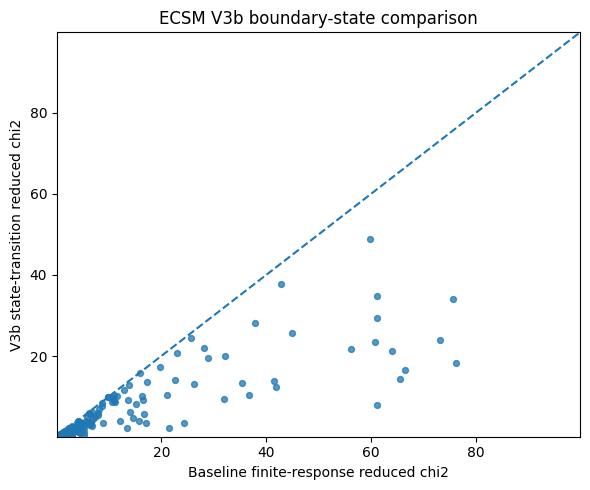

Saved: /content/ecsm_sparc_v3b_boundary_state_transition_out/figures/v3b_state_transition_fit_quality.png


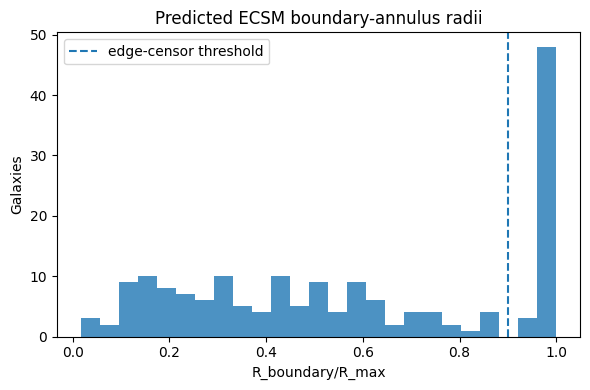

Saved: /content/ecsm_sparc_v3b_boundary_state_transition_out/figures/v3b_predicted_boundary_radius_distribution.png


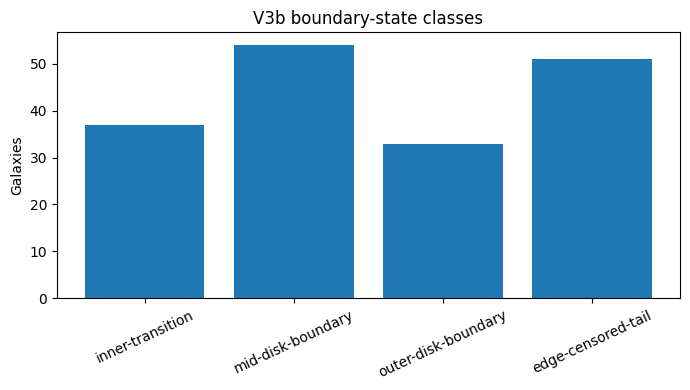

Saved: /content/ecsm_sparc_v3b_boundary_state_transition_out/figures/v3b_boundary_class_counts.png


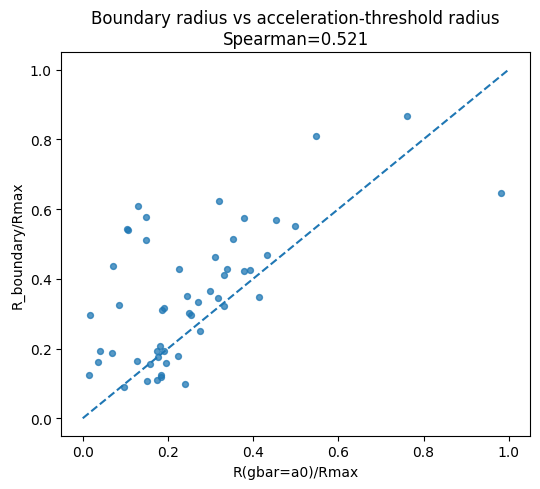

Saved: /content/ecsm_sparc_v3b_boundary_state_transition_out/figures/v3b_boundary_vs_a0_crossing.png


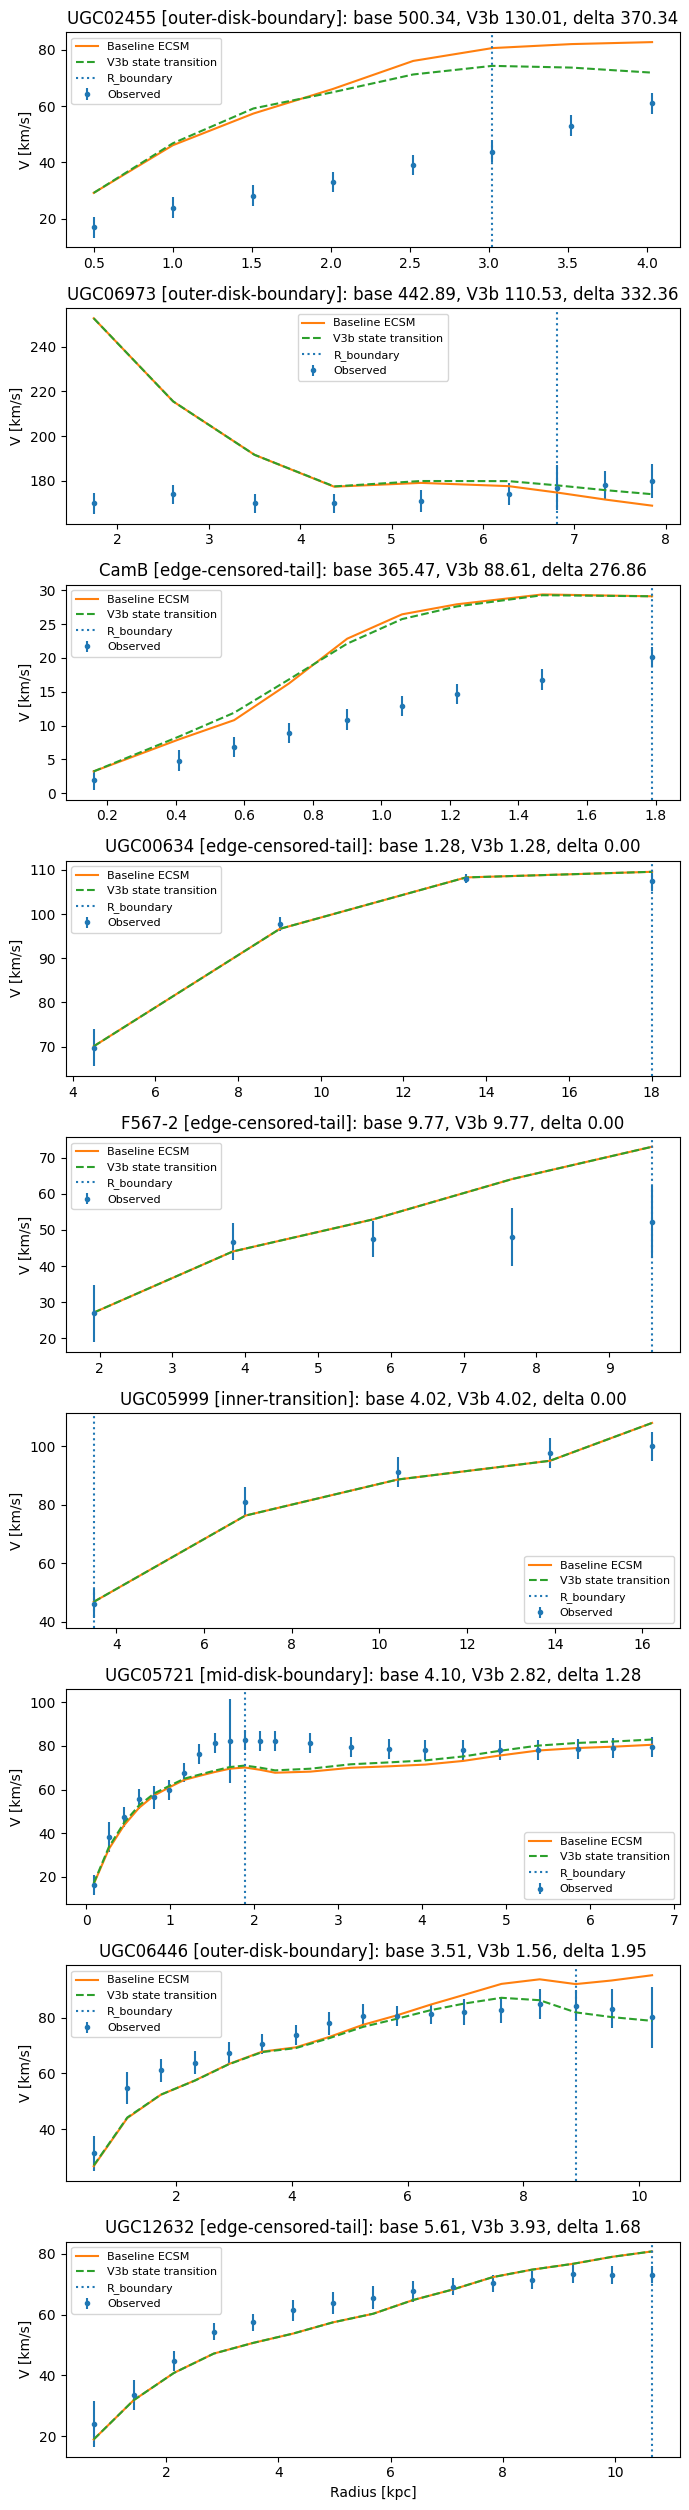

Saved: /content/ecsm_sparc_v3b_boundary_state_transition_out/figures/v3b_state_transition_example_curves.png


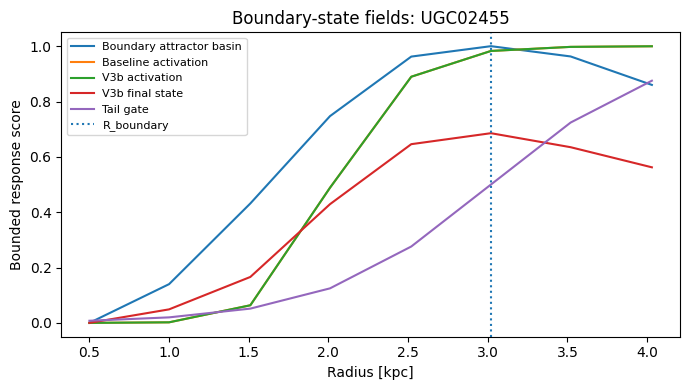

Saved: /content/ecsm_sparc_v3b_boundary_state_transition_out/figures/v3b_boundary_state_field_example.png


In [ ]:
# CELL 08 — FIGURES

def savefig(path):
    plt.tight_layout()
    plt.savefig(path,dpi=220)
    plt.show()
    print('Saved:',path)

p=v3b_summary.replace([np.inf,-np.inf],np.nan).dropna(subset=['base_red_chi2','v3b_red_chi2'])
fig,ax=plt.subplots(figsize=(6,5))
ax.scatter(p.base_red_chi2,p.v3b_red_chi2,s=18,alpha=0.75)
lo=float(np.nanmin([p.base_red_chi2.min(),p.v3b_red_chi2.min()]))
hi=float(np.nanpercentile(np.r_[p.base_red_chi2.values,p.v3b_red_chi2.values],95))
ax.plot([lo,hi],[lo,hi],ls='--')
ax.set(xlabel='Baseline finite-response reduced chi2',ylabel='V3b state-transition reduced chi2',title='ECSM V3b boundary-state comparison',xlim=(lo,hi),ylim=(lo,hi))
savefig(FIGDIR/'v3b_state_transition_fit_quality.png')

fig,ax=plt.subplots(figsize=(6,4))
ax.hist(annulus.R_boundary_over_Rmax.dropna(),bins=25,alpha=.8)
ax.axvline(EDGE_CENSOR_FRAC,ls='--',label='edge-censor threshold')
ax.set(xlabel='R_boundary/R_max',ylabel='Galaxies',title='Predicted ECSM boundary-annulus radii')
ax.legend()
savefig(FIGDIR/'v3b_predicted_boundary_radius_distribution.png')

fig,ax=plt.subplots(figsize=(7,4))
class_counts=annulus.boundary_class.value_counts().reindex(['inner-transition','mid-disk-boundary','outer-disk-boundary','edge-censored-tail']).fillna(0)
ax.bar(class_counts.index.astype(str),class_counts.values)
ax.set(ylabel='Galaxies',title='V3b boundary-state classes')
ax.tick_params(axis='x',rotation=25)
savefig(FIGDIR/'v3b_boundary_class_counts.png')

if len(corr_df)>3:
    fig,ax=plt.subplots(figsize=(5.5,5))
    ax.scatter(corr_df.R_a0_over_Rmax,corr_df.R_boundary_over_Rmax,s=18,alpha=.75)
    ax.plot([0,1],[0,1],ls='--')
    ax.set(xlabel='R(gbar=a0)/Rmax',ylabel='R_boundary/Rmax',title=f'Boundary radius vs acceleration-threshold radius\nSpearman={corr:.3f}')
    savefig(FIGDIR/'v3b_boundary_vs_a0_crossing.png')

# Example curves: best oracle improvements, worst oracle degradations, plus one per class where possible
examples=[]
examples += list(v3b_summary.sort_values('improvement_red_chi2',ascending=False).head(3).galaxy)
examples += list(v3b_summary.sort_values('improvement_red_chi2').head(2).galaxy)
for cls in ['inner-transition','mid-disk-boundary','outer-disk-boundary','edge-censored-tail']:
    sub=v3b_summary[v3b_summary.boundary_class==cls]
    if len(sub): examples.append(sub.iloc[len(sub)//2].galaxy)
examples=list(dict.fromkeys(examples))[:9]
if examples:
    fig,axes=plt.subplots(len(examples),1,figsize=(7,2.8*len(examples)),sharex=False)
    axes=np.atleast_1d(axes)
    for ax,gal in zip(axes,examples):
        g=v3b_curves[v3b_curves.galaxy==gal].sort_values('Rad')
        row=v3b_summary[v3b_summary.galaxy==gal].iloc[0]
        ax.errorbar(g.Rad,g.Vobs,yerr=g.errV,fmt='o',ms=3,label='Observed')
        ax.plot(g.Rad,g.Vmodel,label='Baseline ECSM')
        ax.plot(g.Rad,g.Vv3b,ls='--',label='V3b state transition')
        ax.axvline(row.R_boundary,ls=':',label='R_boundary')
        ax.set_ylabel('V [km/s]')
        ax.set_title(f'{gal} [{row.boundary_class}]: base {row.base_red_chi2:.2f}, V3b {row.v3b_red_chi2:.2f}, delta {row.improvement_red_chi2:.2f}')
        ax.legend(fontsize=8)
    axes[-1].set_xlabel('Radius [kpc]')
    savefig(FIGDIR/'v3b_state_transition_example_curves.png')

if examples:
    gal=examples[0]
    g=v3b_curves[v3b_curves.galaxy==gal].sort_values('Rad')
    fig,ax=plt.subplots(figsize=(7,4))
    ax.plot(g.Rad,g.B_basin,label='Boundary attractor basin')
    ax.plot(g.Rad,g.S,label='Baseline activation')
    ax.plot(g.Rad,g.S_act,label='V3b activation')
    ax.plot(g.Rad,g.S_v3b,label='V3b final state')
    ax.plot(g.Rad,g.tail_gate,label='Tail gate')
    ax.axvline(float(g.R_boundary.iloc[0]),ls=':',label='R_boundary')
    ax.set(xlabel='Radius [kpc]',ylabel='Bounded response score',title=f'Boundary-state fields: {gal}')
    ax.legend(fontsize=8)
    savefig(FIGDIR/'v3b_boundary_state_field_example.png')

In [ ]:
# CELL 09 — EXPORT METRICS, LATEX SNIPPET, AND ZIP EVIDENCE PACKAGE
metrics={
 'N_galaxies':int(v3b_summary.galaxy.nunique()),
 'N_points':int(len(v3b_curves)),
 'oracle_fraction_V3b_improved_red_chi2':float((v3b_summary.improvement_red_chi2>0).mean()),
 'oracle_median_red_chi2_baseline':float(v3b_summary.base_red_chi2.median()),
 'oracle_median_red_chi2_V3b':float(v3b_summary.v3b_red_chi2.median()),
 'oracle_median_red_chi2_improvement':float(v3b_summary.improvement_red_chi2.median()),
 'median_R_boundary_over_Rmax':float(v3b_summary.R_boundary_over_Rmax.median()),
 'fraction_edge_censored':float((v3b_summary.boundary_class=='edge-censored-tail').mean()),
 'spearman_Rboundary_vs_Ra0_excluding_censored':float(corr) if np.isfinite(corr) else np.nan,
}
if 'cv_summary' in globals() and len(cv_summary):
    metrics['CV_delta_chi2']=float(cv_summary.test_delta_chi2.sum())
    metrics['CV_fractional_improvement']=float(cv_summary.test_delta_chi2.sum()/cv_summary.test_base_chi2.sum())
    metrics['CV_fraction_folds_positive']=float((cv_summary.test_delta_chi2>0).mean())
metrics_df=pd.DataFrame([metrics])
metrics_df.to_csv(DATA_DIR/'v3b_boundary_state_transition_metrics_summary.csv',index=False)
metrics_df.T.rename(columns={0:'value'}).to_latex(DATA_DIR/'v3b_boundary_state_transition_metrics_summary.tex',float_format='%.6g')

latex = (
    "\\subsection{V3b boundary-state transition diagnostic}\n"
    f"The V3b notebook treats the inferred response-domain boundary as a state-transition surface rather than as an additive acceleration term. "
    f"Across {metrics['N_galaxies']} SPARC galaxies and {metrics['N_points']} radial points, the structural-oracle V3b fit improves the reduced chi-square for {100*metrics['oracle_fraction_V3b_improved_red_chi2']:.2f}\\% of galaxies. "
    f"The median reduced chi-square changes from {metrics['oracle_median_red_chi2_baseline']:.6g} for the baseline finite-response model to {metrics['oracle_median_red_chi2_V3b']:.6g} for the V3b state-transition model. "
    f"The median inferred boundary location is $R_{{\\rm boundary}}/R_{{\\max}}={metrics['median_R_boundary_over_Rmax']:.3f}$, with an edge-censored fraction of {100*metrics['fraction_edge_censored']:.2f}\\%. "
    f"In the galaxy-held-out shared-law test, the total held-out improvement is $\\Delta\\chi^2_{{\\rm CV}}={metrics.get('CV_delta_chi2',float('nan')):.6g}$, corresponding to a fractional improvement of {metrics.get('CV_fractional_improvement',float('nan')):.6g}. "
    "This diagnostic separates the existence of a structured annular boundary from the stronger claim that a universal state-transition correction has already been derived."
)
(DATA_DIR/'v3b_boundary_state_transition_paper_snippet.tex').write_text(latex)

note="""ECSM SPARC V3b Boundary-State Transition Evidence Note

Theory claim:
Baryons seed a finite-response medium burden. The operative dynamical field is not a direct baryonic force term but the radial gradient of the effective coherence/response-capacity field. V3b treats the inferred boundary as a state-transition surface that can shift activation threshold, broaden relaxation, and alter outer settling memory. Edge-pegged boundaries are treated as right-censored rather than forced internal corrections.

Reduced chain:
rho_b(R) -> Pi_b(R) -> chi(R), tau_resp(R), C_eff(R) -> grad_R C_eff(R) -> g_eff(R)

Metrics:
{}
""".format(metrics_df.to_string(index=False))
(OUTDIR/'v3b_boundary_state_transition_evidence_note.txt').write_text(note)

zip_path=ROOT/'ECSM_SPARC_V3b_boundary_state_transition_outputs.zip'
with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as z:
    for folder in [DATA_DIR,FIGDIR]:
        for p in folder.glob('**/*'):
            if p.is_file(): z.write(p,arcname=str(p.relative_to(OUTDIR)))
    z.write(OUTDIR/'v3b_boundary_state_transition_evidence_note.txt',arcname='v3b_boundary_state_transition_evidence_note.txt')
print('Saved zip:',zip_path)
display(metrics_df.T.rename(columns={0:'value'}))

Saved zip: /content/ECSM_SPARC_V3b_boundary_state_transition_outputs.zip


,value
N_galaxies,175.000000
N_points,3391.000000
oracle_fraction_V3b_improved_red_chi2,0.977143
oracle_median_red_chi2_baseline,5.312955
oracle_median_red_chi2_V3b,3.220804
oracle_median_red_chi2_improvement,1.595904
median_R_boundary_over_Rmax,0.522523
fraction_edge_censored,0.291429
spearman_Rboundary_vs_Ra0_excluding_censored,0.521130
CV_delta_chi2,941.824679


In [ ]:
# CELL 10 — INTERPRETATION TEMPLATE
M=metrics_df.iloc[0]
paragraph=(
f"In V3b, the boundary-gradient attractor is reinterpreted as a response-state transition rather than an additive acceleration term. "
 f"The notebook identifies a boundary annulus for {int(M['N_galaxies'])} galaxies and treats edge-pegged boundaries as right-censored transition radii rather than forcing them into the observed curve. "
 f"The structural-oracle V3b state law improves {100*M['oracle_fraction_V3b_improved_red_chi2']:.2f}% of galaxies, changing the median reduced chi-square from {M['oracle_median_red_chi2_baseline']:.6g} to {M['oracle_median_red_chi2_V3b']:.6g}. "
 f"The median inferred boundary radius is R_boundary/R_max = {M['median_R_boundary_over_Rmax']:.3f}, with {100*M['fraction_edge_censored']:.2f}% of systems classed as edge-censored tails. "
 f"The held-out shared-law result should be reported separately from the oracle result because it is the test of whether the state-transition law is transferable rather than merely structurally descriptive."
)
print(paragraph)

In V3b, the boundary-gradient attractor is reinterpreted as a response-state transition rather than an additive acceleration term. The notebook identifies a boundary annulus for 175 galaxies and treats edge-pegged boundaries as right-censored transition radii rather than forcing them into the observed curve. The structural-oracle V3b state law improves 97.71% of galaxies, changing the median reduced chi-square from 5.31296 to 3.2208. The median inferred boundary radius is R_boundary/R_max = 0.523, with 29.14% of systems classed as edge-censored tails. The held-out shared-law result should be reported separately from the oracle result because it is the test of whether the state-transition law is transferable rather than merely structurally descriptive.
